In [1]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential,Model

from tensorflow.keras.layers import (Embedding,SimpleRNN,LSTM,Bidirectional,Dense,Dropout)

In [2]:
import pandas as pd

df=pd.read_csv("../data/processed/final_features.csv")

In [3]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,total_unique_words,word_share,len_diff,fuzz_ratio,partial_ratio,tfidf_cosine_similarity
0,281827,401637,401638,the twin adarsh and anupam were born in may bu...,twin adarsh and anupam were born in may but th...,1,98,95,18,17,14,17,0.823529,3,98,100,1.000000
1,119174,193562,193563,whi cant i bare to watch someon be humili irlm...,how can you prove mean lifetim formula in radi...,0,129,61,22,10,0,31,0.000000,68,10,32,0.000000
2,18341,34756,2929,my question havent changed whi are they now be...,what happen to a question on quora if it is ma...,1,83,83,13,15,4,23,0.173913,0,53,59,0.481669
3,259132,374863,374864,can anyon tell the program for sequenc 4612183...,what are the next three number in thi series,0,67,47,8,9,1,16,0.062500,20,33,34,0.000000
4,208109,312009,201015,if the civil war occur today who would win,if there wa anoth us civil war north vs south ...,1,46,78,9,16,6,19,0.315789,32,61,50,0.455399


In [4]:
df=df[['question1','question2','is_duplicate']]

In [5]:
df.head()

,question1,question2,is_duplicate
0,the twin adarsh and anupam were born in may bu...,twin adarsh and anupam were born in may but th...,1
1,whi cant i bare to watch someon be humili irlm...,how can you prove mean lifetim formula in radi...,0
2,my question havent changed whi are they now be...,what happen to a question on quora if it is ma...,1
3,can anyon tell the program for sequenc 4612183...,what are the next three number in thi series,0
4,if the civil war occur today who would win,if there wa anoth us civil war north vs south ...,1


<!-- Question Pair
      ↓
Tokenizer
      ↓
Word Sequences
      ↓
Embedding Layer
      ↓
LSTM/BiLSTM
      ↓
Prediction -->

In [6]:
df.isnull().sum()

question1       3
question2       0
is_duplicate    0
dtype: int64

In [7]:
df.dropna(inplace=True)


In [8]:
df.isnull().sum()

question1       0
question2       0
is_duplicate    0
dtype: int64

# Tokenization

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer=Tokenizer(
    num_words=50000,
    oov_token='<OOV>'
)

all_questions=(
    df['question1'].astype(str).tolist()+df['question2'].astype(str).tolist()
)

tokenizer.fit_on_texts(all_questions)

In [10]:
#conver text->sequence

q1_seq=tokenizer.texts_to_sequences(
    df['question1'].astype(str)
)

q2_seq=tokenizer.texts_to_sequences(
    df['question2'].astype(str)
)

### Padding


In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN=50

q1_pad=pad_sequences(q1_seq,maxlen=MAX_LEN,padding='post')

q2_pad=pad_sequences(q2_seq,maxlen=MAX_LEN,padding='post')

In [12]:
#here we have to send both questions and encoder will work on it so we will need 2 sets of train set

In [13]:
X1_train,X1_test,X2_train,X2_test,y_train,y_test=train_test_split(q1_pad,q2_pad,df['is_duplicate'],test_size=0.2,random_state=42,stratify=df['is_duplicate'])

### Prepare single input for RNN

In [14]:
X_train = np.concatenate(
    [X1_train, X2_train],
    axis=1
)

X_test = np.concatenate(
    [X1_test, X2_test],
    axis=1
)

In [15]:
print(X_train.shape)
print(X_test.shape)

(59391, 100)
(14848, 100)


# Simple RNN model

In [16]:
#rnn is san with MAX_LEN=30 while tokenization and rest are with MAX_LEN=50

In [17]:
rnn_model=Sequential()

rnn_model.add(
    Embedding(
        input_dim=50000,
        output_dim=128,
        
    )
)

rnn_model.add(
    SimpleRNN(
        64,
        
    )
)


rnn_model.add(Dense(1,activation='sigmoid'))

In [18]:
#compile

rnn_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [20]:
history_rnn=rnn_model.fit(X_train,y_train,validation_split=0.2,epochs=10,batch_size=64,callbacks=[early_stop])

Epoch 1/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - accuracy: 0.5026 - loss: 0.6954 - val_accuracy: 0.5096 - val_loss: 0.6953
Epoch 2/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 80s 69ms/step - accuracy: 0.5085 - loss: 0.6945 - val_accuracy: 0.5214 - val_loss: 0.6934
Epoch 3/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.5132 - loss: 0.6934 - val_accuracy: 0.5215 - val_loss: 0.6919
Epoch 4/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 54s 72ms/step - accuracy: 0.5157 - loss: 0.6926 - val_accuracy: 0.4995 - val_loss: 0.6949
Epoch 5/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.5128 - loss: 0.6930 - val_accuracy: 0.5225 - val_loss: 0.6919
Epoch 6/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.5162 - loss: 0.6926 - val_accuracy: 0.5229 - val_loss: 0.6921
Epoch 7/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 51s 69ms/step - accuracy: 0.5143 - loss: 0.6928 - val_accuracy: 0.4996 - val_loss: 0.6941


In [21]:
rnn_loss,rnn_acc=rnn_model.evaluate(
    X_test,
    y_test
)

print(rnn_acc)

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5223 - loss: 0.6919
0.5222925543785095


### storing result

In [22]:
results_df = pd.read_csv('model_results.csv')

results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982
1,Random Forest,TF-IDF,0.743080,0.704847,0.836342,0.764985
2,XGB_BOOST,TF-IDF,0.752845,0.701136,0.881331,0.780974


In [23]:
y_pred_prob = rnn_model.predict(X_test)

464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [24]:
y_pred = (y_pred_prob > 0.5).astype(int)

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision: " , precision)
print("recall: ",recall)
print("f1: ",f1)

Precision:  0.5145341178536929
recall:  0.7891971982758621
f1:  0.6229333900377438


In [29]:
new_row=pd.DataFrame([{
    "model":"SimpleRnn",
    "feature":"Deep Learning Approach",
    "accuracy":rnn_acc,
    "precision":precision,
    "recall":recall,
    "f1":f1
}])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [30]:
results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982
1,Random Forest,TF-IDF,0.743080,0.704847,0.836342,0.764985
2,XGB_BOOST,TF-IDF,0.752845,0.701136,0.881331,0.780974
3,SimpleRnn,Deep Learning Approach,0.522293,0.514534,0.789197,0.622933


# LSTM

In [31]:
lstm_model=Sequential()

lstm_model.add(Embedding(input_dim=50000,output_dim=128))

lstm_model.add(LSTM(128))
lstm_model.add(Dense(64,activation='relu'))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1, activation='sigmoid'))

In [32]:
lstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [34]:
history_lstm=lstm_model.fit(X_train,y_train,validation_split=0.2,epochs=10,batch_size=128,callbacks=[early_stop])

Epoch 1/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 71s 185ms/step - accuracy: 0.5060 - loss: 0.6947 - val_accuracy: 0.5018 - val_loss: 0.6931
Epoch 2/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 67s 179ms/step - accuracy: 0.5045 - loss: 0.6948 - val_accuracy: 0.5026 - val_loss: 0.6922
Epoch 3/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 67s 179ms/step - accuracy: 0.5415 - loss: 0.6754 - val_accuracy: 0.6820 - val_loss: 0.5970
Epoch 4/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 68s 183ms/step - accuracy: 0.7195 - loss: 0.5520 - val_accuracy: 0.7149 - val_loss: 0.5521
Epoch 5/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 68s 184ms/step - accuracy: 0.8012 - loss: 0.4383 - val_accuracy: 0.7145 - val_loss: 0.5721
Epoch 6/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 68s 183ms/step - accuracy: 0.8520 - loss: 0.3460 - val_accuracy: 0.7085 - val_loss: 0.6365


In [35]:
lstm_loss,lstm_acc=lstm_model.evaluate(
    X_test,y_test
)

print(lstm_acc)

464/464 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7212 - loss: 0.5501
0.7211745977401733


In [36]:
y_pred_prob = lstm_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

464/464 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step


In [38]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision: " , precision)
print("recall: ",recall)
print("f1: ",f1)


Precision:  0.7411160058737152
recall:  0.6798221982758621
f1:  0.7091471125474217


In [39]:
new_row=pd.DataFrame([{
    "model":"LSTM",
    "feature":"Deep Learning Approach",
    "accuracy":lstm_acc,
    "precision":precision,
    "recall":recall,
    "f1":f1
}])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [40]:
results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982
1,Random Forest,TF-IDF,0.743080,0.704847,0.836342,0.764985
2,XGB_BOOST,TF-IDF,0.752845,0.701136,0.881331,0.780974
3,SimpleRnn,Deep Learning Approach,0.522293,0.514534,0.789197,0.622933
4,LSTM,Deep Learning Approach,0.721175,0.741116,0.679822,0.709147


# BiLSTM

In [41]:
bilstm_model=Sequential()

bilstm_model.add(Embedding(input_dim=50000,output_dim=128))
bilstm_model.add(Bidirectional(LSTM(64)))
bilstm_model.add(Dense(1,activation='sigmoid'))

In [42]:
# compile

bilstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [43]:
history_bilstm=bilstm_model.fit(X_train,y_train,validation_split=0.2,epochs=10,batch_size=128,callbacks=[early_stop])

Epoch 1/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 59s 152ms/step - accuracy: 0.6783 - loss: 0.5927 - val_accuracy: 0.7177 - val_loss: 0.5517
Epoch 2/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 61s 164ms/step - accuracy: 0.7633 - loss: 0.4932 - val_accuracy: 0.7157 - val_loss: 0.5633
Epoch 3/10
372/372 ━━━━━━━━━━━━━━━━━━━━ 57s 154ms/step - accuracy: 0.8116 - loss: 0.4173 - val_accuracy: 0.7132 - val_loss: 0.5960


In [44]:
bilstm_loss,bilstm_acc=bilstm_model.evaluate(X_test,y_test)

print(bilstm_acc)

464/464 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7224 - loss: 0.5522
0.7223868370056152


In [45]:
y_pred_prob = bilstm_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

464/464 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step


In [46]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision: " , precision)
print("recall: ",recall)
print("f1: ",f1)


Precision:  0.7449554896142433
recall:  0.6763200431034483
f1:  0.708980513979102


In [47]:
new_row=pd.DataFrame([{
    "model":"BiLSTM",
    "feature":"Deep Learning Approach",
    "accuracy":bilstm_acc,
    "precision":precision,
    "recall":recall,
    "f1":f1
    
}])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [48]:
results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982
1,Random Forest,TF-IDF,0.743080,0.704847,0.836342,0.764985
2,XGB_BOOST,TF-IDF,0.752845,0.701136,0.881331,0.780974
3,SimpleRnn,Deep Learning Approach,0.522293,0.514534,0.789197,0.622933
4,LSTM,Deep Learning Approach,0.721175,0.741116,0.679822,0.709147
5,BiLSTM,Deep Learning Approach,0.722387,0.744955,0.676320,0.708981


# Siamese Network

### BUILD ENCODER

In [81]:
from tensorflow.keras.layers import Input

VOCAB_SIZE=50000
MAX_LEN=50
input_layer=Input(shape=(MAX_LEN,))

In [82]:
# EMBEDDING

x=Embedding(input_dim=VOCAB_SIZE,output_dim=128)(input_layer)

In [83]:
#Lstm

x=LSTM(64)(x)

In [84]:
#craete encoder

encoder=Model(input_layer,x)

In [85]:
#creating two inputs

input_q1=Input(shape=(MAX_LEN,))
input_q2=Input(shape=(MAX_LEN,))

In [86]:
#pass input through Encoder

encoded_q1=encoder(input_q1)
encoded_q2=encoder(input_q2)

In [87]:
# merge representations

In [88]:
from tensorflow.keras.layers import Concatenate

In [89]:
merged=Concatenate()([encoded_q1,encoded_q2])

In [90]:
x=Dense(128,activation='relu')(merged)

x=Dropout(0.3)(x)

x=Dense(64,activation='relu')(x)

output=Dense(1,activation='sigmoid')(x)

In [91]:
#build final model

siamese_model=Model(
    inputs=[input_q1,input_q2],
    outputs=output
)

In [92]:
siamese_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [93]:
history=siamese_model.fit([X1_train,X2_train],y_train,validation_split=0.2,epochs=5,batch_size=128)

Epoch 1/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.4993 - loss: 0.6932 - val_accuracy: 0.5478 - val_loss: 0.6775
Epoch 2/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 40s 109ms/step - accuracy: 0.6603 - loss: 0.6132 - val_accuracy: 0.6884 - val_loss: 0.5930
Epoch 3/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.7343 - loss: 0.5352 - val_accuracy: 0.6906 - val_loss: 0.5777
Epoch 4/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.7776 - loss: 0.4832 - val_accuracy: 0.6969 - val_loss: 0.5946
Epoch 5/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.8077 - loss: 0.4394 - val_accuracy: 0.7076 - val_loss: 0.5996


In [94]:
siamese_loss,siamese_acc=siamese_model.evaluate(
    [X1_test,X2_test],
    y_test
)

print(siamese_acc)

464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7097 - loss: 0.5938
0.7097252011299133


In [96]:
y_pred_prob = siamese_model.predict([X1_test,X2_test])
y_pred = (y_pred_prob > 0.5).astype(int)

464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


In [97]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision: " , precision)
print("recall: ",recall)
print("f1: ",f1)


Precision:  0.6942850012478163
recall:  0.7494612068965517
f1:  0.7208187589065941


In [106]:
new_row=pd.DataFrame([
    {
        "model":"Siamese",
        "feature":"Dl approach",
        "accuracy":siamese_acc,
        "precision":precision,
        "recall":recall,
        "f1":f1
    }
])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [110]:
results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982
1,Random Forest,TF-IDF,0.743080,0.704847,0.836342,0.764985
2,XGB_BOOST,TF-IDF,0.752845,0.701136,0.881331,0.780974
3,SimpleRnn,Deep Learning Approach,0.522293,0.514534,0.789197,0.622933
4,LSTM,Deep Learning Approach,0.721175,0.741116,0.679822,0.709147
5,BiLSTM,Deep Learning Approach,0.722387,0.744955,0.676320,0.708981
7,Siamese,Dl approach,0.709725,0.694285,0.749461,0.720819


In [111]:
preds = siamese_model.predict(
    [X1_test, X2_test]
)

464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [112]:
preds = (preds > 0.5).astype(int)

In [113]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.73      0.67      0.70      7424
           1       0.69      0.75      0.72      7424

    accuracy                           0.71     14848
   macro avg       0.71      0.71      0.71     14848
weighted avg       0.71      0.71      0.71     14848



In [114]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [115]:
print(history.history['accuracy'])

[0.4993054270744324, 0.6602542400360107, 0.7342566251754761, 0.777571976184845, 0.8077327609062195]


In [116]:
print(history.history['val_accuracy'])

[0.5477733612060547, 0.6883575916290283, 0.6906304955482483, 0.6968600153923035, 0.7076353430747986]


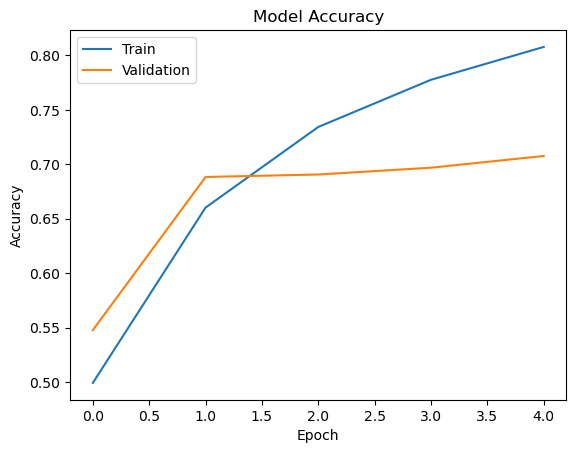

In [117]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

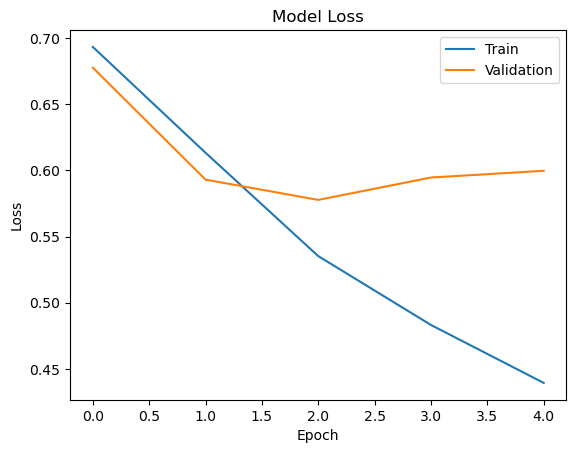

In [118]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [119]:
results_df.to_csv("model_results.csv", index=False)

In [120]:
results_df

,model,feature,accuracy,precision,recall,f1
0,Logistic Regression,TF-IDF,0.687117,0.663681,0.758621,0.707982
1,Random Forest,TF-IDF,0.743080,0.704847,0.836342,0.764985
2,XGB_BOOST,TF-IDF,0.752845,0.701136,0.881331,0.780974
3,SimpleRnn,Deep Learning Approach,0.522293,0.514534,0.789197,0.622933
4,LSTM,Deep Learning Approach,0.721175,0.741116,0.679822,0.709147
5,BiLSTM,Deep Learning Approach,0.722387,0.744955,0.676320,0.708981
7,Siamese,Dl approach,0.709725,0.694285,0.749461,0.720819


### Conclusion 

Classical feature engineering combined with XGBoost achieved the best performance (73.8% accuracy) on the 50k sample dataset, outperforming the tested deep learning architectures. This suggests that carefully engineered lexical and semantic features remain highly effective for duplicate question detection on medium-sized datasets.